# Q6+Q7.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

In [3]:
import seaborn as sns

In [4]:
import statsmodels.api as sm

In [5]:
from pygam import f as gmf, s as gms, LinearGAM

In [ ]:
wage = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Wage.csv')

In [7]:
wage.sample(3)

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
302,2005,25,1. Never Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.397940,81.283253
448,2003,48,2. Married,1. White,4. College Grad,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.892095,133.232351
60,2005,43,2. Married,1. White,4. College Grad,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.029384,152.838801


# Q6.
```{admonition}
:class: note
In this exercise, you will further analyze the `Wage` data set considered throughout this chapter.

## (a)
```{admonition}
:class: note
Perform polynomial regression to predict `wage` using `age`. Use cross-validation to select the optimal degree $d$ for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.

In [35]:
X = wage[['age']]
y = wage['wage']

In [151]:
def best_low_complexity(cv_results):
    best_score_idx = np.argmax(cv_results["mean_test_score"])
    thresh = cv_results["mean_test_score"][best_score_idx] - cv_results["std_test_score"][best_score_idx]/10
    candidate_idx = np.flatnonzero(cv_results["mean_test_score"] >= thresh)
    best_idx = candidate_idx[
        cv_results["param_poly__degree"][candidate_idx].argmin()
    ]
    return best_idx

In [36]:
pipe = Pipeline(
    [
        ('poly',PolynomialFeatures(include_bias=True)),('lr',LinearRegression(fit_intercept=False))
    ]

)
inner_cv = KFold(shuffle=True,random_state=1728,n_splits=10)
outer_cv = KFold(shuffle=True,random_state=1729,n_splits=10)
degrees = np.arange(12)

#gridsearch = GridSearchCV(pipe,{'poly__degree':degrees},scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1,refit=best_low_complexity)
gridsearch = GridSearchCV(pipe,{'poly__degree':degrees},scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1)
cv_mse = -cross_val_score(gridsearch,X,y,cv=outer_cv).mean()

gridsearch.fit(X,y)
best_degree = gridsearch.best_params_['poly__degree']

print(f'CV average MSE: {cv_mse:.4f}')
print(f'Degree used: {best_degree}')

CV average MSE: 1596.7416
Degree used: 7


In [37]:
Xs = [PolynomialFeatures(include_bias=True,degree=d).fit_transform(X) for d in range(8)]
ano_res = sm.stats.anova_lm(*[sm.OLS(y,x).fit() for x in Xs]).replace(np.nan,-np.inf)
print(ano_res)

   df_resid           ssr  df_diff       ss_diff           F        Pr(>F)
0    2999.0  5.222086e+06      0.0          -inf        -inf          -inf
1    2998.0  5.022216e+06      1.0  1.998697e+05  125.553046  1.412341e-28
2    2997.0  4.793430e+06      1.0  2.287860e+05  143.717560  2.226663e-32
3    2996.0  4.777674e+06      1.0  1.575569e+04    9.897327  1.671425e-03
4    2995.0  4.771604e+06      1.0  6.070152e+03    3.813115  5.094581e-02
5    2994.0  4.770322e+06      1.0  1.282563e+03    0.805674  3.694747e-01
6    2993.0  4.766389e+06      1.0  3.932258e+03    2.470144  1.161330e-01
7    2993.0  4.764599e+06     -0.0  1.790513e+03        -inf          -inf


In [38]:
best_anova_degree = ano_res[ano_res['Pr(>F)']>0.05].index[0]-1
print(f'Degree chosen by ANOVA: {best_anova_degree}')

Degree chosen by ANOVA: 3


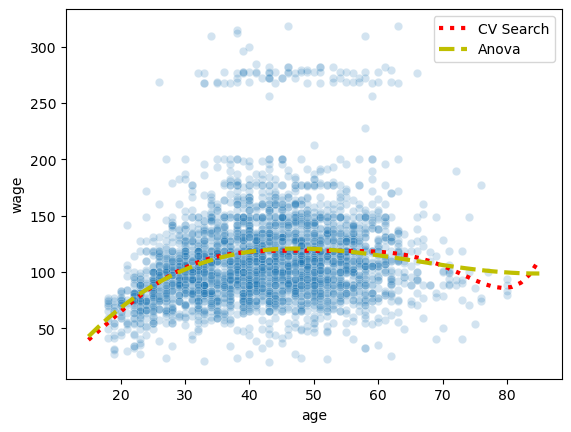

In [39]:
pipe.named_steps['poly'].degree = best_degree
pipe.fit(X,y)
xs = np.linspace(15,85)
xs_cv = np.array([[x**d for d in range(best_degree+1)] for x in xs])
lr_coef = pipe.named_steps['lr'].coef_
ys_cv = xs_cv @ lr_coef
plt.plot(xs,ys_cv,'r:',linewidth=3,label='CV Search')

anova_model = sm.OLS(y,PolynomialFeatures(include_bias=True,degree=best_anova_degree).fit_transform(X)).fit()
xs_anov = np.array([[x**d for d in range(3+1)] for x in xs])
ys_anov = anova_model.predict(xs_anov)
plt.plot(xs,ys_anov,color='y',linestyle='--',linewidth=3,label='Anova')

sns.scatterplot(wage,x='age',y='wage',alpha=0.2)
plt.show()

## (b)
```{admonition}
:class: note
Fit a step function to predict `wage` using `age`, and perform cross-validation to choose the optimal number of cuts. Make a plot of the fit obtained.

In [40]:
pipe_step = Pipeline(
    [
        ('bin',KBinsDiscretizer(strategy='uniform')),('linreg',LinearRegression(fit_intercept=False))
    ]
)

inner_cv = KFold(shuffle=True,random_state=1728,n_splits=10)
outer_cv = KFold(shuffle=True,random_state=1729,n_splits=10)
cuts = np.arange(2,26)

gridsearch_step = GridSearchCV(pipe_step,{'bin__n_bins':cuts},scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1)
cv_step_mse = -cross_val_score(gridsearch_step,X,y,cv=outer_cv).mean()

gridsearch_step.fit(X,y)
best_cuts = gridsearch_step.best_params_['bin__n_bins']

print(f'CV average MSE: {cv_step_mse:.4f}')
print(f'Cuts used: {best_cuts}')

CV average MSE: 1613.1039
Cuts used: 16


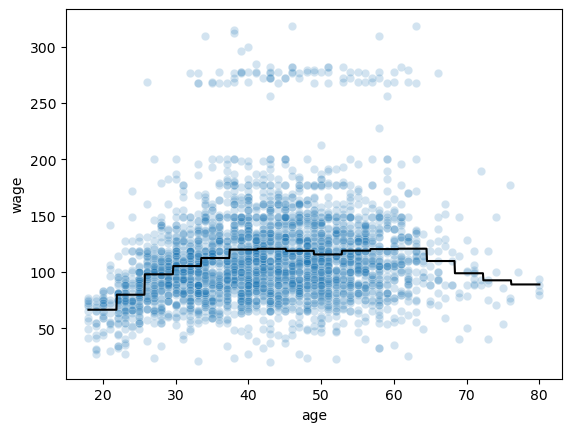

In [41]:
pipe_step.named_steps['bin'].n_bins = best_cuts
pipe_step.fit(X.values,y)
xs = np.linspace(X.min(),X.max(),1000)
ys = pipe_step.predict(xs)

plt.plot(xs,ys,'k-')
sns.scatterplot(wage,x='age',y='wage',alpha=0.2)
plt.show()

# Q7.
```{admonition}
:class: note
The `Wage` data set contains a number of other features not explored in this chapter, such as marital status (`maritl`), job class (`jobclass`), and others. Explore the relationships between some of these other predictors and `wage`, and use non-linear fitting techniques in order to fit flexible models to the data. Create plots of the results obtained.

In [58]:
wage.sample(3)

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
2219,2004,61,2. Married,1. White,2. HS Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.397940,81.283253
835,2009,68,2. Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.770852,118.019753
2974,2003,46,2. Married,2. Black,2. HS Grad,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,4.778151,118.884359


In [33]:
X = wage[['year']]
pipe = Pipeline(
    [
        ('poly',PolynomialFeatures(include_bias=True)),('lr',LinearRegression(fit_intercept=False))
    ]

)
inner_cv = KFold(shuffle=True,random_state=1728,n_splits=10)
outer_cv = KFold(shuffle=True,random_state=1729,n_splits=10)
degrees = np.arange(12)

#gridsearch = GridSearchCV(pipe,{'poly__degree':degrees},scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1,refit=best_low_complexity)
gridsearch = GridSearchCV(pipe,{'poly__degree':degrees},scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1)
cv_mse = -cross_val_score(gridsearch,X,y,cv=outer_cv).mean()

gridsearch.fit(X,y)
best_degree = gridsearch.best_params_['poly__degree']

print(f'CV average MSE: {cv_mse:.4f}')
print(f'Degree used: {best_degree}')

CV average MSE: 1734.7369
Degree used: 1


In [10]:
Xs = [PolynomialFeatures(include_bias=True,degree=d).fit_transform(X) for d in range(8)]
ano_res = sm.stats.anova_lm(*[sm.OLS(y,x).fit() for x in Xs]).replace(np.nan,-np.inf)
print(ano_res)

   df_resid           ssr  df_diff       ss_diff          F    Pr(>F)
0    2999.0  5.222086e+06      0.0          -inf       -inf      -inf
1    2998.0  5.199651e+06      1.0  2.243435e+04  12.933990  0.000328
2    2997.0  5.198366e+06      1.0  1.285420e+03   0.741078  0.389385
3    2997.0  5.198368e+06     -0.0 -2.231879e+00        inf      -inf
4    2997.0  5.198370e+06     -0.0 -2.238601e+00        inf      -inf
5    2997.0  5.198373e+06     -0.0 -2.245460e+00        inf      -inf
6    2997.0  5.198375e+06     -0.0 -2.251846e+00        inf      -inf
7    2997.0  5.198377e+06     -0.0 -2.257911e+00        inf      -inf


In [11]:
best_anova_degree = ano_res[ano_res['Pr(>F)']>0.05].index[0]-1
print(f'Degree chosen by ANOVA: {best_anova_degree}')

Degree chosen by ANOVA: 1


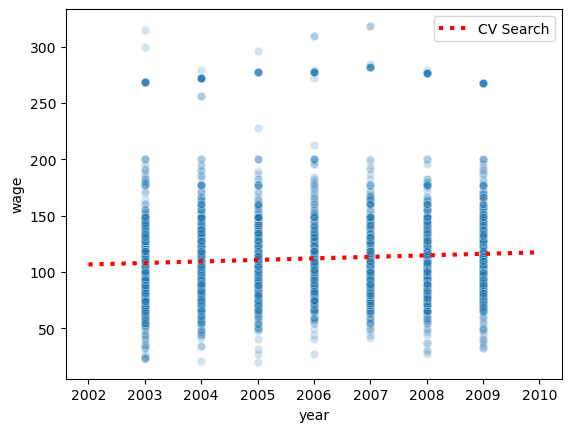

In [34]:
lr = LinearRegression()
lr.fit(X,y)
xs = np.linspace(2002,2010)
ys_cv = lr.intercept_+xs*lr.coef_[0]
plt.plot(xs,ys_cv,'r:',linewidth=3,label='CV Search')

sns.scatterplot(wage,x='year',y='wage',alpha=0.2)
plt.show()

In [44]:
rng = np.random.default_rng(1728)

def gamfit(df:pd.DataFrame,cols:list,target:str) -> LinearGAM:
    y = df[target]
    X = df[cols]
    categorical_cols = [col for col in X.select_dtypes(include=['category','object','str'])]
    terms = [gmf(i) if col in categorical_cols else gms(i) for i,col in enumerate(cols)]
    X[categorical_cols] = X[categorical_cols].apply(lambda col: col.astype('category').cat.codes)
    gam = LinearGAM(np.sum(terms))
    return gam.gridsearch(X,y,lam=np.exp(rng.random(size=(100, len(cols))) * 6 - 3))

def gamplot(gam:LinearGAM,df:pd.DataFrame,cols:list,target:str):
    fig, axs = plt.subplots(1, len(cols),figsize=(20,4))
    for i, ax in enumerate(axs):
        XX = gam.generate_X_grid(term=i)
        ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
        ax.plot(
            XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1], c="r", ls="--"
        )
        ax.set_title(cols[i])

In [45]:
wage_year_fix = wage.copy()
wage_year_fix['year'] = pd.Categorical(wage_year_fix['year'])

feats = ['age','year','maritl','health','education','jobclass']

gammod = gamfit(wage_year_fix,feats,'wage')

100% (100 of 100) |######################| Elapsed Time: 0:00:02 Time:  0:00:020000


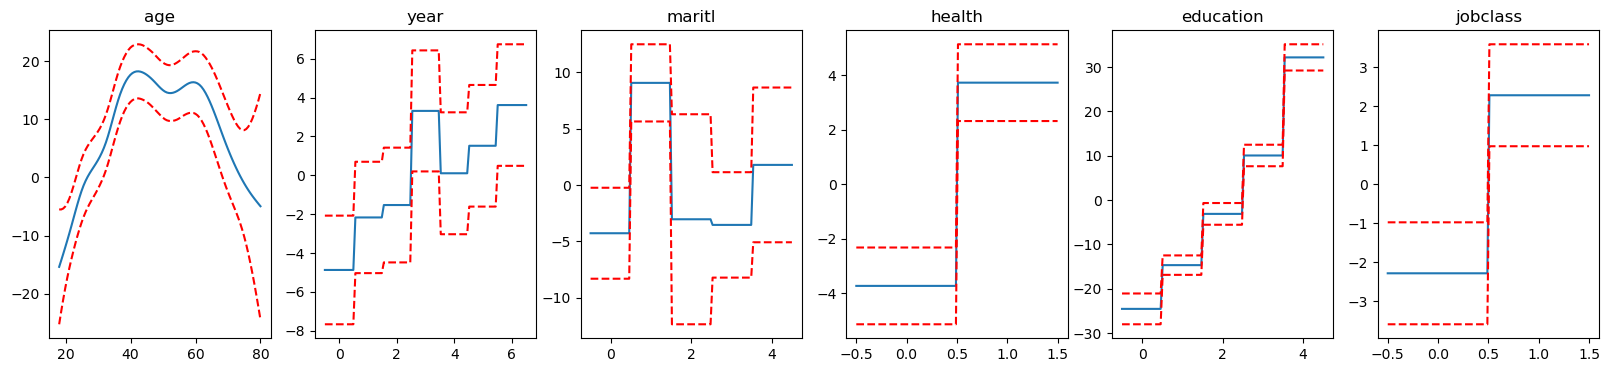

In [46]:
gamplot(gammod,wage,feats,'wage')

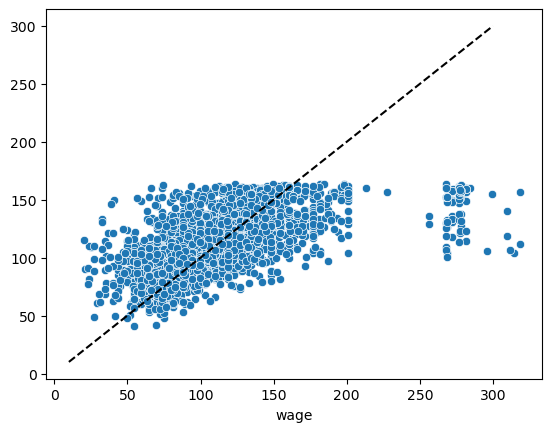

In [47]:
wage_fix = wage.apply(lambda col: col.astype('category').cat.codes)
wage_fix[['age','wage']] = wage[['age','wage']]

sns.scatterplot(x=wage_fix['wage'],y=gammod.predict(wage_fix[feats]));
xs = np.linspace(10,300)
plt.plot(xs,xs,'k--')
plt.show()

In [48]:
print(mean_squared_error(wage['wage'],gammod.predict(wage_fix[feats])))
print(r2_score(wage['wage'],gammod.predict(wage_fix[feats])))

1181.2702993841233
0.32138018132410207


In [43]:
print(mean_squared_error(wage['wage'],np.ones(wage.shape[0])*wage['wage'].mean()))

1740.6952565708757
